# Explore first dataset (M2) — MET004TESTBLUE, R01

Loads the EEGLAB run, shows the channel name <-> index correspondence, loads the
blue-intensity stimulus levels for the 20 stimulus trials, and compares the
spectrum of Oz against O1 and O2.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from eeg.blue_stimulus import load_blue_levels
from eeg.eeglab_io import BASELINE_EVENT_ID, load_eeglab_epochs
from eeg.psd import combine_channels, compute_psd

In [2]:
DATA_ROOT = Path("/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/eegExp/compsRem")
BLUE_TEST_ROOT = Path("/home/zevaz/projects/metamers/eeg/ssvepBLUETEST")
PARTICIPANT = "MET004TESTBLUE"
RUN = "R01"

epochs = load_eeglab_epochs(DATA_ROOT / PARTICIPANT / f"{RUN}.mat")
print(epochs)

Not setting metadata


23 matching events found


No baseline correction applied


0 projection items activated


<EpochsArray | 23 events (all good), 0 – 2.998 s (baseline off), ~8.7 MiB, data loaded,
 'baseline': 3
 'stimulus': 20>


## Channel name <-> index correspondence

`mne.Epochs`/`EpochsArray` already gives this for free via `ch_names` — no new
helper needed. This order matches the channel axis of `epochs.get_data()` and
of `tf` arrays returned by `eeg.timefreq.time_frequency_decompose`.

In [3]:
name_to_index = {name: i for i, name in enumerate(epochs.ch_names)}

for ch in ["Oz", "O1", "O2"]:
    idx = epochs.ch_names.index(ch)  # equivalently: name_to_index[ch]
    print(f"{ch:>3s} -> index {idx:2d}  (round-trip: epochs.ch_names[{idx}] = {epochs.ch_names[idx]!r})")

 Oz -> index  2  (round-trip: epochs.ch_names[2] = 'Oz')
 O1 -> index  1  (round-trip: epochs.ch_names[1] = 'O1')
 O2 -> index  3  (round-trip: epochs.ch_names[3] = 'O2')


## Blue stimulus levels

`blueArray` in `{participant}BlueTest.npz` gives the blue PWM intensity used in
each of the 20 stimulus trials, in the same order as R01's stimulus trials
(`EEG.data` trials 4:23).

In [4]:
blue_levels = load_blue_levels(BLUE_TEST_ROOT / f"{PARTICIPANT}BlueTest.npz")
stim_trial_idx = np.where(epochs.events[:, 2] != BASELINE_EVENT_ID)[0]

print(f"{len(blue_levels)} blue levels for {len(stim_trial_idx)} stimulus trials")
for trial, level in zip(stim_trial_idx, blue_levels):
    print(f"  trial {trial:2d} (epoch #{trial+1:2d}): blue level = {level:8.2f}")

20 blue levels for 20 stimulus trials
  trial  3 (epoch # 4): blue level =     0.00
  trial  4 (epoch # 5): blue level =   131.58
  trial  5 (epoch # 6): blue level =   263.16
  trial  6 (epoch # 7): blue level =   394.74
  trial  7 (epoch # 8): blue level =   526.32
  trial  8 (epoch # 9): blue level =   657.89
  trial  9 (epoch #10): blue level =   789.47
  trial 10 (epoch #11): blue level =   921.05
  trial 11 (epoch #12): blue level =  1052.63
  trial 12 (epoch #13): blue level =  1184.21
  trial 13 (epoch #14): blue level =  1315.79
  trial 14 (epoch #15): blue level =  1447.37
  trial 15 (epoch #16): blue level =  1578.95
  trial 16 (epoch #17): blue level =  1710.53
  trial 17 (epoch #18): blue level =  1842.11
  trial 18 (epoch #19): blue level =  1973.68
  trial 19 (epoch #20): blue level =  2105.26
  trial 20 (epoch #21): blue level =  2236.84
  trial 21 (epoch #22): blue level =  2368.42
  trial 22 (epoch #23): blue level =  2500.00


## Spectrum comparison: Oz vs O1 vs O2

`eeg.psd.compute_psd` — Welch PSD per channel, per trial (M3) — then
`combine_channels` selects/averages the channels of interest; trials are
averaged here at the call site for a single line per channel.

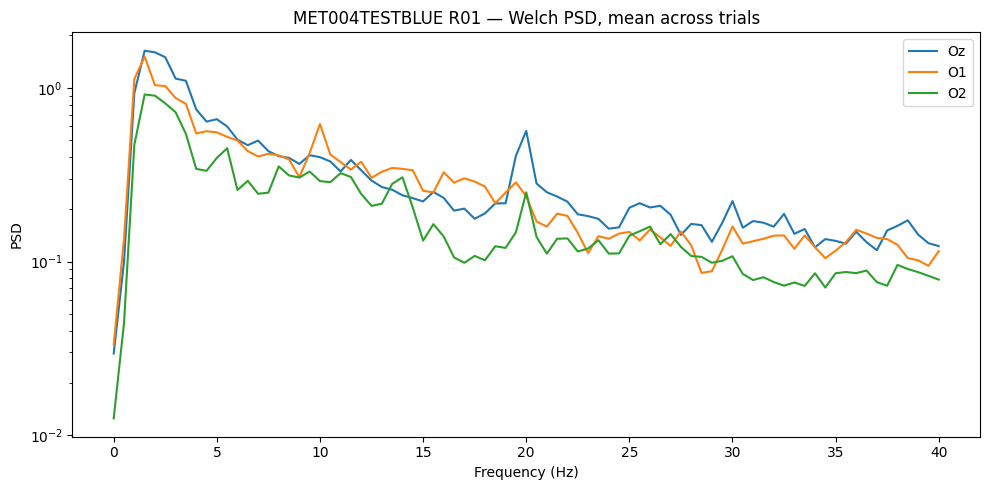

In [5]:
sfreq = epochs.info["sfreq"]
data = epochs.get_data()  # (n_trials, n_channels, n_times)

freqs, psd = compute_psd(data, sfreq)  # (n_channels, n_freqs, n_trials)
freq_mask = freqs <= 40  # plot range; keeps the y-axis from autoscaling to the Nyquist edge

fig, ax = plt.subplots(figsize=(10, 5))
for ch in ["Oz", "O1", "O2"]:
    spectrum = combine_channels(psd, epochs.ch_names, channels=[ch])  # (n_freqs, n_trials)
    ax.semilogy(freqs[freq_mask], spectrum.mean(axis=-1)[freq_mask], label=ch)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title(f"{PARTICIPANT} {RUN} — Welch PSD, mean across trials")
ax.legend()
fig.tight_layout()